## Práctica 1: Niveles Linguisticos

In [1]:
import requests as r
import http
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import editdistance

## Parte 1: Fonética
### Objetivo
Con base en el sistema de búsqueda de la Práctica 1 (recibe una palabra
ortográfica y devuelve su transcripción fonológica desde el diccionario IPA),
se propone una solución para los casos en que la **palabra no se encuentra**
en el lexicón.

### Estrategia
Se utiliza la **distancia de edición (Levenshtein)** para encontrar la
palabra ortográficamente más cercana en el diccionario y devolver su
transcripción fonológica como aproximación.

In [2]:
IPA_URL = "https://raw.githubusercontent.com/open-dict-data/ipa-dict/master/data/{lang}.txt"

In [3]:
def download_ipa_corpus(iso_lang: str) -> str:
    print(f"descargando {iso_lang}", end="::")
    respuesta = r.get(IPA_URL.format(lang=iso_lang))
    status_code = respuesta.status_code
    print(f"código de estatus: {status_code}")
    if status_code != http.HTTPStatus.OK:
        print(f"Error al descargar el corpus para {iso_lang}")
        return ""
    return respuesta.text

In [4]:
def parse_response(response: str) -> dict:
    ipa_list = response.rstrip().split("\n")
    result = {}
    for x in ipa_list:
        if x == "":
            continue
        x_list = x.split("\t")
        result[x_list[0]] = x_list[1]
    return result

In [5]:
def get_ipa_transcription(word: str, dataset: dict) -> list[str]:
    return dataset.get(word.lower()," ").split(", ")

In [6]:
es_data = parse_response(download_ipa_corpus("es_MX"))

descargando es_MX::código de estatus: 200


In [7]:
get_ipa_transcription("mayonesa", es_data)

['/maʝonesa/']

### Función mejorada: `get_transcripcion`
Si la palabra existe en el corpus, devuelve su transcripción directamente.
Si **no existe**, busca la palabra con menor distancia de edición y
devuelve su transcripción como aproximación.

In [8]:
def get_transcripcion(palabra, dataset):
    if palabra not in dataset:
        print(f"la palabra {palabra} no se encuentra en el corpus")
        print(f"buscando la palabra con distancia de edición más cercana")
        min = float("inf")
        cpalabra = ""
        for w in dataset.keys():
            if editdistance.eval(palabra, w) < min:
                min = editdistance.eval(palabra, w)
                cpalabra = w
        print(f"palabra con distancia de edición más cercana:")
        return cpalabra, get_ipa_transcription(cpalabra, dataset)
    else:
        return get_ipa_transcription(palabra, dataset)

In [9]:
get_transcripcion("marihuanos", es_data)

la palabra marihuanos no se encuentra en el corpus
buscando la palabra con distancia de edición más cercana
palabra con distancia de edición más cercana:


('marianos', ['/maɾjanos/'])

### Tres ejemplos de palabras no encontradas en el diccionario:

In [10]:
print(get_transcripcion("exelente", es_data))
print(get_transcripcion("fuistes", es_data))
print(get_transcripcion("empresta",es_data))
print(get_transcripcion("salte",es_data))

la palabra exelente no se encuentra en el corpus
buscando la palabra con distancia de edición más cercana
palabra con distancia de edición más cercana:
('excelente', ['/eksselente/'])
la palabra fuistes no se encuentra en el corpus
buscando la palabra con distancia de edición más cercana
palabra con distancia de edición más cercana:
('fuiste', ['/fwiste/'])
la palabra empresta no se encuentra en el corpus
buscando la palabra con distancia de edición más cercana
palabra con distancia de edición más cercana:
('empresa', ['/empɾesa/'])
['/salte/']


## Parte 2: la venganza de los morfemas
### Objetivo
Elegir tres lenguas de familias lingüísticas distintas, calcular métricas
morfológicas y compararlas.

### Lenguas seleccionadas
| Lengua   | Familia lingüística | Código |
|----------|---------------------|--------|
| Húngaro  | **Urálica**         | `hun`  |
| Inglés   | **Germánica**       | `eng`  |
| Ruso     | **Eslava**          | `rus`  |

In [11]:
LANGS = {
    "ces": "Czech",
    "eng": "English",
    "fra": "French",
    "hun": "Hungarian",
    "spa": "Spanish",
    "ita": "Italian",
    "lat": "Latin",
    "rus": "Russian",
}
CATEGORIES = {
    "100": "Inflection",
    "010": "Derivation",
    "101": "Inflection, Compound",
    "000": "Root",
    "011": "Derivation, Compound",
    "110": "Inflection, Derivation",
    "001": "Compound",
    "111": "Inflection, Derivation, Compound"
}

In [12]:
def get_track_files(lang: str, track: str = "word") -> list[str]:
    return[
        f"{lang}.{track}.test.gold",
        f"{lang}.{track}.dev"
    ]

In [13]:
def get_raw_corpus(files: list) -> list:
    resultado = []
    for f in files:
        print(f"descargando {f}.tsv", end="::")
        respuesta = r.get(f"https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/{f}.tsv")
        print(f"código de estatus: {respuesta.status_code}")
        lineas = respuesta.text.rstrip().split("\n")
        resultado.extend(lineas[:-1])
    return resultado

In [14]:
track_files = get_track_files("rus")
raw_corpus = get_raw_corpus(track_files)

descargando rus.word.test.gold.tsv::código de estatus: 200
descargando rus.word.dev.tsv::código de estatus: 200


In [15]:
raw_corpus[0]

'арестовывавшую\tарест @@овать @@ывать @@вший @@ую\t110'

In [16]:
def raw_corpus_to_dataframe(corpus_list: list, lang: str) -> pd.DataFrame:
    data_list = []
    for line in corpus_list:
        try:
            word, tagged_data, category = line.split("\t")
        except ValueError:
            # Caso donde no existe la categoria
            word, tagged_data = line.split("\t")
            category = "NOT_FOUND"
        morphemes: list = tagged_data.split()
        data_list.append(
            {"words": word, "morph": morphemes, "category": category, "lang": lang}
        )
    df = pd.DataFrame(data_list)
    df["word_len"] = df["words"].apply(lambda word: len(word))
    df["morph_count"] = df["morph"].apply(lambda list: len(list))
    return df

# Obtenemos 3 corpus distintos:

In [17]:
efiles = get_track_files("eng")
raw_corpus = get_raw_corpus(efiles)
df_eng = raw_corpus_to_dataframe(raw_corpus, "eng")

descargando eng.word.test.gold.tsv::código de estatus: 200
descargando eng.word.dev.tsv::código de estatus: 200


In [18]:
rfiles = get_track_files("rus")
raw_corpus = get_raw_corpus(rfiles)
df_rus = raw_corpus_to_dataframe(raw_corpus, "rus")

descargando rus.word.test.gold.tsv::código de estatus: 200
descargando rus.word.dev.tsv::código de estatus: 200


In [19]:
hfiles = get_track_files("hun")
raw_corpus = get_raw_corpus(hfiles)
df_hun= raw_corpus_to_dataframe(raw_corpus, "hun")

descargando hun.word.test.gold.tsv::código de estatus: 200
descargando hun.word.dev.tsv::código de estatus: 200


In [20]:
df_eng.head(20)

,words,morph,category,lang,word_len,morph_count
0,subsidised,"[subside, @@y, @@ise, @@ed]",110,eng,10,4
1,merchandizes,"[merchandize, @@s]",100,eng,12,2
2,undiscounted,"[un, @@discount, @@ed]",110,eng,12,3
3,immoveables,"[in, @@move, @@able, @@s]",110,eng,11,4
4,leucocratic,"[leuco, @@cratic]",010,eng,11,2
5,ginzos,"[ginzo, @@s]",100,eng,6,2
6,incompatibility,"[in, @@compatible, @@ity]",010,eng,15,3
7,stillatories,"[stillatory, @@s]",100,eng,12,2
8,Eskies,"[Eskimo, @@ie, @@s]",110,eng,6,3
9,Italophone,"[Italo, @@phone]",010,eng,10,2


In [21]:
df_rus.head(20)

,words,morph,category,lang,word_len,morph_count
0,арестовывавшую,"[арест, @@овать, @@ывать, @@вший, @@ую]",110,rus,14,5
1,духовников,"[духовник, @@ов]",100,rus,10,2
2,передачу,"[пере, @@дать, @@ча, @@у]",110,rus,8,4
3,прижавшегося,"[при, @@жать, @@вший, @@его, @@ся]",110,rus,12,5
4,аннексированы,"[аннексия, @@ировать, @@нный, @@ы]",110,rus,13,4
5,шпингалету,"[шпингалет, @@у]",100,rus,10,2
6,сионистское,"[сионист, @@ский, @@ое]",110,rus,11,3
7,крошащим,"[крошить, @@ат, @@щий, @@им]",100,rus,8,4
8,обежала,"[о, @@бежать, @@л, @@а]",110,rus,7,4
9,спугивавшая,"[с, @@пугнуть, @@ивать, @@вший, @@ая]",110,rus,11,5


In [22]:
df_hun.head(20)
#

,words,morph,category,lang,word_len,morph_count
0,pöfetegből,"[pöfeteg, @@ből]",100,hun,10,2
1,pleonazmus,[pleonazmus],000,hun,10,1
2,világháborúsakban,"[világ, @@háború, @@s, @@ak, @@ban]",111,hun,17,5
3,lugashoz,"[lugas, @@hoz]",100,hun,8,2
4,Fokvárosra,"[fok, @@vár, @@os, @@ra]",111,hun,10,4
5,faljátok,"[fal, @@játok]",100,hun,8,2
6,ászanáké,"[ászana, @@k, @@é]",100,hun,8,3
7,kirakata,"[ki, @@rak, @@at, @@a]",110,hun,8,4
8,kopoltyúkat,"[kopoltyú, @@k, @@at]",100,hun,11,3
9,közösségeké,"[köz, @@ös, @@ség, @@ek, @@é]",110,hun,11,5


### Métrica 1: Ratio morfemas / palabra
Promedio de morfemas que componen las palabras en cada lengua.

In [23]:
def ratio_morfemas(df):
    cant_palabras = len(df)
    cant_morfemas = df.morph_count.sum()
    
    return cant_palabras, float(cant_morfemas / cant_palabras)

### Métrica 2: Índice de Flexión y Derivación
Del total de palabras, ¿qué porcentaje tienen etiqueta de flexión (`100`)
y cuáles de derivación (`010`)?

In [24]:
def indice_flexion(df):
    cant_palabras = len(df)
    flex = df[df["category"]=="100"]
    flex_len = len(flex)
    indice = (float(flex_len/cant_palabras))*100
    print(f"El índice de flexión es: {indice}%")
    return indice
    


In [25]:
def indice_derivacion(df):
    cant_palabras = len(df)
    derivacion = df[df["category"]=="010"]
    der_len = len(derivacion)
    indiceder = (float(der_len/cant_palabras))*100
    print(f"El índice de derivación es: {indiceder}%")
    return indiceder
    


In [26]:
ratio_morfemas(df_hun)

(188072, 3.230278829384491)

In [27]:
ratio_morfemas(df_eng)

(115124, 2.3532451964837913)

In [28]:
ratio_morfemas(df_rus)

(156844, 3.8515786386473185)

## Indices de flexión y derivación del Húngaro:

In [29]:
print(indice_flexion(df_hun))
print(indice_derivacion(df_hun))

El índice de flexión es: 41.09277298056064%
41.09277298056064
El índice de derivación es: 2.9355778637968437%
2.9355778637968437


## Indices de flexión y derivación del Inglés:

In [30]:
print(indice_flexion(df_eng))
print(indice_derivacion(df_eng))

El índice de flexión es: 21.056426114450506%
21.056426114450506
El índice de derivación es: 36.57360758833953%
36.57360758833953


## Indice de flexión y derivación del Ruso

In [31]:
print(indice_flexion(df_rus))
print(indice_derivacion(df_rus))

El índice de flexión es: 28.275866466042693%
28.275866466042693
El índice de derivación es: 9.487133712478641%
9.487133712478641


In [32]:
def limpia_morfemas(df):
    limpio = []
    for x in df.morph:
        xlimpio = str(x).replace("@@", "")
        suelto = xlimpio.split()
        for y in suelto:
            limpio.append(len(y))
    return limpio

## Limpiamos los morfemas para obtener la lóngitud de cada uno de ellos y los guardamos

In [33]:
limpia_hun = limpia_morfemas(df_hun)
limpia_eng = limpia_morfemas(df_eng)
limpia_rus = limpia_morfemas(df_rus)

## Graficamos

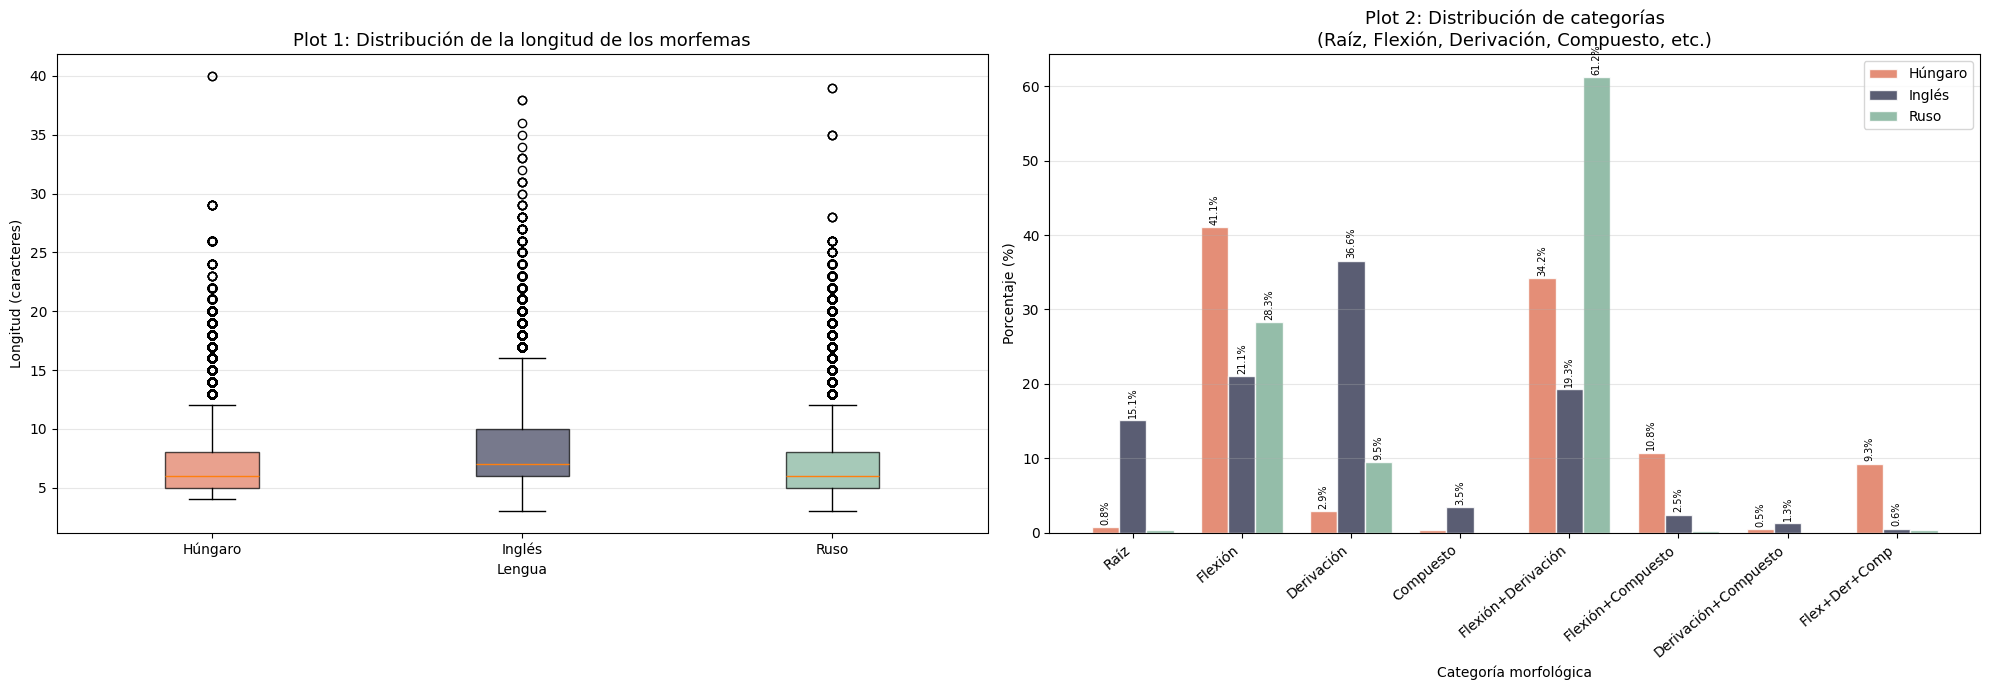


RESUMEN COMPARATIVO
Lengua       Palabras   Ratio morf/pal     Flexión %    Derivación %   Raíz %
-----------------------------------------------------------------
Húngaro      188072     3.23               41.1         2.9            0.8
Inglés       115124     2.35               21.1         36.6           15.1
Ruso         156844     3.85               28.3         9.5            0.4


In [34]:
CATEGORIES = {
    "000": "Raíz",
    "100": "Flexión",
    "010": "Derivación",
    "001": "Compuesto",
    "110": "Flexión+Derivación",
    "101": "Flexión+Compuesto",
    "011": "Derivación+Compuesto",
    "111": "Flex+Der+Comp",
}

lang_labels = ["Húngaro", "Inglés", "Ruso"]
dfs = [df_hun, df_eng, df_rus]
colors = ["#e07a5f", "#3d405b", "#81b29a"]

all_cats_in_data = set()
for df in dfs:
    all_cats_in_data.update(df["category"].unique())

all_cats_in_data.discard("NOT_FOUND")

cat_keys = [k for k in CATEGORIES.keys() if k in all_cats_in_data]
extras = sorted(all_cats_in_data - set(CATEGORIES.keys()))
cat_keys.extend(extras)

cat_labels = [CATEGORIES.get(k, k) for k in cat_keys]

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

bp = axs[0].boxplot(
    [limpia_hun, limpia_eng, limpia_rus],
    tick_labels=lang_labels,
    patch_artist=True,
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axs[0].set_title("Plot 1: Distribución de la longitud de los morfemas", fontsize=13)
axs[0].set_ylabel("Longitud (caracteres)")
axs[0].set_xlabel("Lengua")
axs[0].grid(axis="y", alpha=0.3)

counts_per_lang = []
for df in dfs:
    total = len(df)
    counts = []
    for k in cat_keys:
        cnt = len(df[df["category"] == k])
        counts.append((cnt / total) * 100 if total else 0)
    counts_per_lang.append(counts)

x = np.arange(len(cat_labels))
width = 0.25

for i, (lang, counts, color) in enumerate(
    zip(lang_labels, counts_per_lang, colors)
):
    bars = axs[1].bar(
        x + i * width, counts, width,
        label=lang, color=color, alpha=0.85, edgecolor="white"
    )
    # Etiquetas de porcentaje sobre cada barra
    for bar, val in zip(bars, counts):
        if val > 0.5:  # solo mostrar si es > 0.5%
            axs[1].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{val:.1f}%",
                ha="center", va="bottom", fontsize=7, rotation=90
            )

axs[1].set_xticks(x + width)
axs[1].set_xticklabels(cat_labels, rotation=40, ha="right", fontsize=10)
axs[1].set_title(
    "Plot 2: Distribución de categorías\n(Raíz, Flexión, Derivación, Compuesto, etc.)",
    fontsize=13,
)
axs[1].set_ylabel("Porcentaje (%)")
axs[1].set_xlabel("Categoría morfológica")
axs[1].legend(loc="upper right")
axs[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("morfologia_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "="*65)
print("RESUMEN COMPARATIVO")
print("="*65)
print(f"{'Lengua':<12} {'Palabras':<10} {'Ratio morf/pal':<18} {'Flexión %':<12} {'Derivación %':<14} {'Raíz %'}")
print("-"*65)

for label, df in zip(lang_labels, dfs):
    total = len(df)
    _, ratio = ratio_morfemas(df)
    flex = len(df[df["category"] == "100"]) / total * 100
    deriv = len(df[df["category"] == "010"]) / total * 100
    raiz = len(df[df["category"] == "000"]) / total * 100
    print(f"{label:<12} {total:<10} {ratio:<18.2f} {flex:<12.1f} {deriv:<14.1f} {raiz:.1f}")

## Análisis
Notemos que una lengua aislante tiene un ratio de morfemas/palabras más pequeño o cercano a 1 pues usa menos morfemas por palabras, en este caso, el húngaro se comporta como aglutinante con morfemas más cortos y numerosos, su indice de flexión es tambien bastante más alto, en contraste el inglés se comporta como una lengua aislante pues su ratio de morfemas y palabras es menor y su indice de flexión es mucho menor que el del húngaro, en el caso del ruso se comporta como una lengua fusionante pues usa mucho más morfemas por palabra (más que el húngaro) y tiene un indice de flexión elevado(no tan alto como el húngaro) y además los morfemas del ruso fusionan varios rasgos en uno, mientras que el húngaro los separa en sufijos individuales.

En resumen:
El húngaro es aglutinante.
El inglés es aislante.
El ruso es fusionante.
